In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import plt_conf as conf
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

conf.general()

In [2]:
## Variables and equations
z, q0, j0 = sp.symbols('z q0 j0', real=True)
f_val, k_val = 1.0, 1.0

# --- H(z) and derivatives" ---
H = 1 + (1 + q0)*z + sp.Rational(1,2)*(-q0**2 + j0)*z**2
Hp = sp.diff(H, z)

dH = Hp * (-1/(1/(1+z))**2) * H / (1+z)**2
dHp = sp.diff(dH, z)

ddH = dHp * (-1/(1/(1+z))**2) * H / (1+z)**2

# --- rho(z) y derivatives ---
rho = 0.33*(1+z)**3 + 0.66
rhop = sp.diff(rho, z)
drho = rhop * (-1/(1/(1+z))**2) * H / (1+z)**2

# --- Phi(z) ---
f, k = sp.symbols('f k')
Phi = (f*(1/(1+z))**9 * (
        3*(1/(1+z))*(2*H**3 - ddH)*rho
        + ((1/(1+z))*H**2 + (1/(1+z))*dH)*drho
      )) / (108*k*((1/(1+z))*H**2 + (1/(1+z))*dH)**4)

Phi_num = Phi.subs({f: f_val, k: k_val})
Phi_func = sp.lambdify((z, q0, j0), Phi_num, modules='numpy')


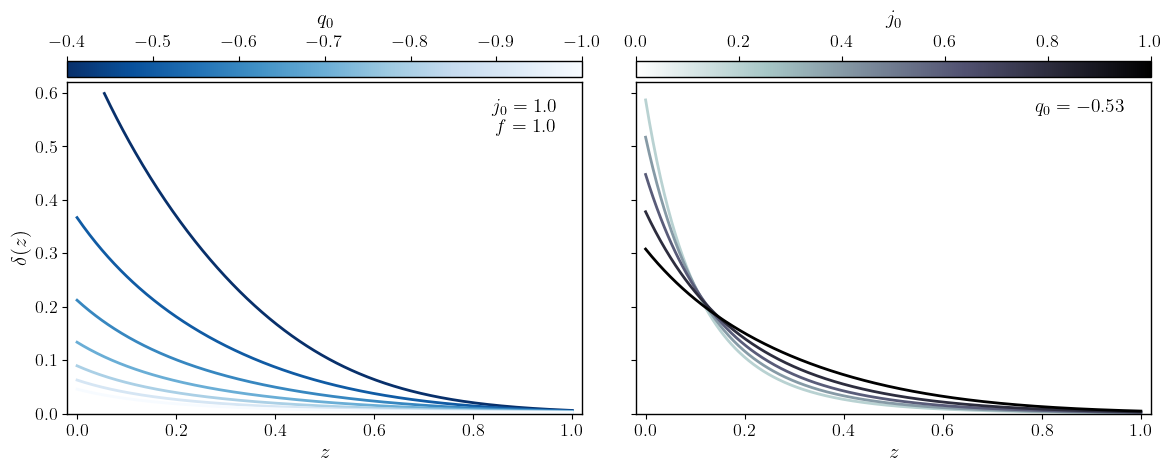

In [3]:
##Plot
z_vals = np.linspace(0, 1, 400)

# --- Parámetros fijos de cada panel ---
q0_fixed_for_j0plot = -0.53
j0_fixed_for_q0plot = 1.0

# --- Rango de valores a barrer ---
q0_vals = np.arange(-0.4, -1.0 - 1e-9, -0.1)
j0_vals = np.arange(0, 1.0 + 1e-9, 0.2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# ---------------- Izquierda: variación de q0 ----------------
ax = axes[0]
ax.set_ylim(top=0.62)
ax.set_xlim(-0.02, 1.02)
norm_q = Normalize(vmin=q0_vals.min(), vmax=q0_vals.max())
cmap_q = cm.Blues
for qv in q0_vals:
    y_vals = Phi_func(z_vals, qv, j0_fixed_for_q0plot)
    y_vals_clipped = np.where(y_vals > 0.6, np.nan, y_vals)  # corta la curva al llegar al límite
    ax.plot(z_vals, y_vals_clipped, color=cmap_q(norm_q(qv)), lw=2)

ax.set_xlabel("$z$")
ax.set_ylabel(r"$\delta(z)$")
#ax.grid(True, alpha=0.3)

divider = make_axes_locatable(ax)
cax = divider.append_axes("top", size="5%", pad=0.05)
sm_q = cm.ScalarMappable(norm=norm_q, cmap=cmap_q)
sm_q.set_array([])
cb_q = fig.colorbar(sm_q, cax=cax, orientation="horizontal")
cb_q.ax.xaxis.set_ticks_position("top")
cb_q.ax.xaxis.set_label_position("top")
cb_q.set_label(r"$q_0$",labelpad=7.5)
cb_q.ax.invert_xaxis()
ax.text(0.95, 0.95,
        f"$j_0={j0_fixed_for_q0plot:.1f}$\n$f={f_val:.1f}$",
        transform=ax.transAxes, va="top", ha="right", fontsize=14)

# ---------------- Derecha: variación de j0 ----------------
ax = axes[1]
ax.set_xlim(-0.02, 1.02)
norm_j = Normalize(vmin=j0_vals.min(), vmax=j0_vals.max())
cmap_j = cm.bone_r
for jv in j0_vals:
    y_vals = Phi_func(z_vals, q0_fixed_for_j0plot, jv)
    ax.plot(z_vals, y_vals, color=cmap_j(norm_j(jv)), lw=2)

ax.set_xlabel("$z$")
#ax.grid(True, alpha=0.3)
ax.tick_params(labelleft=False)

divider = make_axes_locatable(ax)
cax = divider.append_axes("top", size="5%", pad=0.05)
sm_j = cm.ScalarMappable(norm=norm_j, cmap=cmap_j)
sm_j.set_array([])
cb_j = fig.colorbar(sm_j, cax=cax, orientation="horizontal")
cb_j.ax.xaxis.set_ticks_position("top")
cb_j.ax.xaxis.set_label_position("top")
cb_j.set_label(r"$j_0$",labelpad=7.5)

ax.text(0.95, 0.95,
        "$q_0=-0.53$",
        transform=ax.transAxes, va="top", ha="right", fontsize=14)

plt.tight_layout()
plt.show()
fig.savefig("../Plots/deltas.pdf", bbox_inches="tight")

